<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
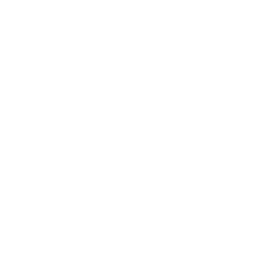
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">Efterfrågeprognos för receptbelagda läkemedel</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; Läkemedel / Planering av leveranskedja &nbsp;|&nbsp; mars 2026</p>
</div>
</div>
</div>

## Sammanfattning

En regional distributör måste dimensionera åtaganden för tillverkning och lager för **CARDIOSTAT 40MG**, en underhållsbehandling mot hjärt-kärlsjukdom med stadig efterfrågan på förnyade recept. Denna notebook bygger en Box-Jenkins-prognos av månatlig receptexpedieringsvolym från **100 månaders (drygt åtta år) historik** och projicerar efterfrågan tolv månader framåt för planering av leveranskedjan.

Arbetsflödet följer de tre stegen i PROC ARIMA. **IDENTIFY** undersöker autokorrelationen (ACF) och partiella autokorrelationen (PACF) för den första-differentierade serien för att välja en modellordning. **ESTIMATE** anpassar en ARIMA(1,1,1) med maximum likelihood och fångar parametertabellen via ODS OUTPUT för dokumentation. **FORECAST** genererar en bana tolv månader framåt med 95-procentiga prediktionsintervall.

Den anpassade ARIMA(1,1,1) ger en i huvudsak **platt central prognos på cirka 105,400 expedieringar per månad**, med ett 95-procentigt intervall som vidgas till ungefär **[71,800; 138,900]** vid månad tolv. Varken AR- eller MA-termen är statistiskt signifikant på detta urval, så modellen beter sig nära en slumpvandring med drift — en försvarbar, konservativ grund för förpositionering av lager. Varje siffra som anges nedan är tagen direkt från den körda utdatan.

## Datakällor

| Källa | Beskrivning | Poster |
|--------|-------------|--------|
| WORK.DRUG_DEMAND | Syntetiska månatliga receptexpedieringsvolymer för en NDC (från jan 1984 och framåt) | 100 |
| WORK.FORECASTS | PROC ARIMA OUT=-dataset: anpassade värden + 12-månadersprognos och intervall | 112 |

Efterfrågeserien genereras syntetiskt med en linjär tillväxttrend, en årlig säsongscykel och autokorrelerat brus, och prognostiseras sedan med PROC ARIMA.

---

In [1]:
/* --------------------------------------------------------
   Skapa syntetisk manatlig efterfragan pa recept:
   100 manader (~8 ar) av uttagsvolym, med start jan 1984.
   Struktur = linjar trend + arlig sasong + AR-brus.
   -------------------------------------------------------- */
data work.drug_demand;
    CALL streaminit(42);
    ndc_code  = '12345-6789-01';
    drug_name = 'CARDIOSTAT 40MG';
    base_demand = 85000;
    trend = 120;
    prev_error = 0;
    GÖR month_seq = 1 TILL 100;
        demand_date = intnx('month', '01JAN1984'd, month_seq - 1);
        year      = year(demand_date);
        month_num = month(demand_date);
        /* arlig + halvarlig sasongskomponent */
        seasonal = 4000 * sin(2 * constant('PI') * month_num / 12)
                 + 2000 * cos(2 * constant('PI') * month_num / 6);
        random_shock = round(rand('normal', 0, 3500));
        /* autoregressiv overforing fran foregaende storning */
        ar_component = 0.6 * prev_error;
        fill_volume = round(base_demand + trend * month_seq + seasonal
                      + ar_component + random_shock);
        OM fill_volume < 10000 SÅ fill_volume = 10000;
        prev_error = random_shock;
        revenue = round(fill_volume * 4.85, 0.01);
        UTDATA;
    SLUT;
    TA_BORT base_demand trend seasonal random_shock ar_component
         prev_error month_num;
    ETIKETT demand_date="Månad" year="År"
          fill_volume="Antal recept" revenue="Intäkt";
    format demand_date monyy7. revenue dollar12.2;
KÖR;


NOTE: DATA work.drug_demand


NOTE: Wrote work.drug_demand (100 rows, 7 columns).
NOTE: DATA elapsed:
  wall  0.02 seconds
  cpu   0.02 seconds


---

In [2]:
/* --------------------------------------------------------
   Arlig sammanfattning av efterfragan: medel/spridning av
   manatliga uttag och intakter per kalenderar i serien.
   -------------------------------------------------------- */
PROCEDUR MEDELVÄRDEN data=work.drug_demand n mean std MIN MAX maxdec=0;
    KLASS year;
    VARIABEL fill_volume revenue;
    ETIKETT year="År" fill_volume="Antal recept" revenue="Intäkt";
    TITEL "Årlig sammanfattning av läkemedelsefterfrågan: CARDIOSTAT 40MG";
KÖR;

                             Årlig sammanfattning av läkemedelsefterfrågan: CARDIOSTAT 40MG                             

                                                  The MEANS Procedure

                                      Analysis Variable : fill_volume Antal recept

        År                N Obs           Mean        Std Dev        Minimum        Maximum
        -----------------------------------------------------------------------------------
        1984                 12          83534           5857          74202          90189
        1985                 12          86676           5080          78290          92470
        1986                 12          87213           4266          79050          91718
        1987                 12          91119           5476          78822          97289
        1988                 12          94218           5885          84353         102556
        1989                 12          94877           4895          86493   


NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


---

                             Årlig sammanfattning av läkemedelsefterfrågan: CARDIOSTAT 40MG                             




NOTE: PROC SGPLOT data=work.drug_demand

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


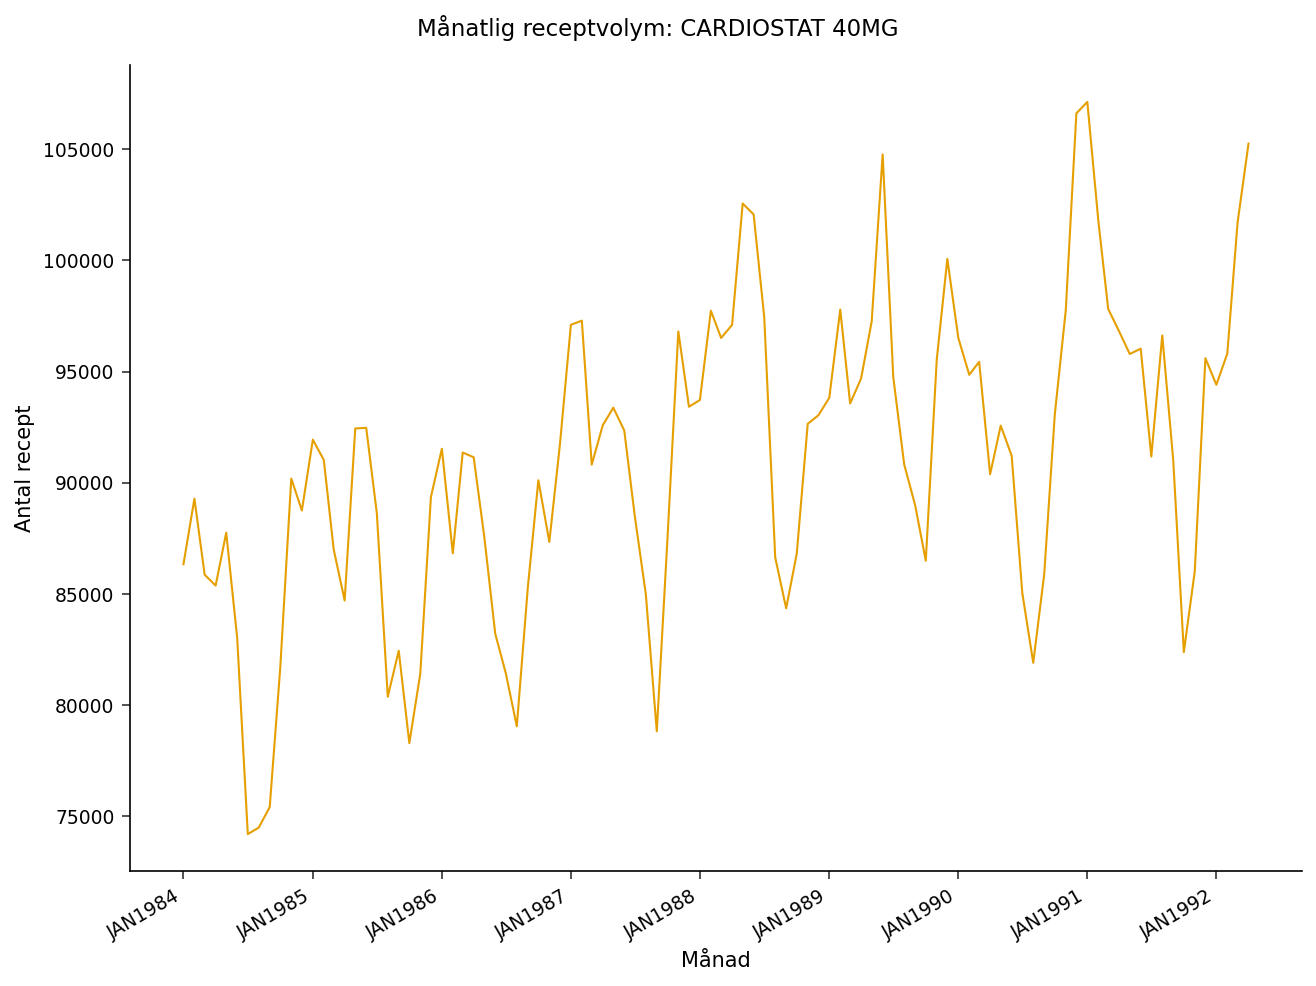

In [3]:
/* --------------------------------------------------------
   Tidsseriediagram over manatliga uttagsvolymer
   -------------------------------------------------------- */
PROCEDUR SGPLOT data=work.drug_demand;
    SERIES x=demand_date y=fill_volume / LINEATTRS=(thickness=1);
    XAXIS ETIKETT="Månad";
    YAXIS ETIKETT="Antal recept";
    TITEL "Månatlig receptvolym: CARDIOSTAT 40MG";
KÖR;

                             Årlig sammanfattning av läkemedelsefterfrågan: CARDIOSTAT 40MG                             

The ARIMA Procedure

Name of Variable = Antal recept

Number of Observations    100

Descriptive Statistics

  Mean             90982.5600
  Std Dev           6905.4488
  Minimum          74202.0000
  Maximum         107123.0000

Autocorrelations

  Lag    Correlation    Std Error
  ---    -----------    ---------
  Lag   1     0.744824     0.100000
  Lag   2     0.433078     0.100000
  Lag   3     0.247230     0.100000
  Lag   4     0.105029     0.100000
  Lag   5     0.006433     0.100000
  Lag   6     0.047404     0.100000
  Lag   7     0.061895     0.100000
  Lag   8     0.037422     0.100000
  Lag   9     0.070910     0.100000
  Lag  10     0.181341     0.100000
  Lag  11     0.321225     0.100000
  Lag  12     0.442194     0.100000
  Lag  13     0.463728     0.100000
  Lag  14     0.346773     0.100000
  Lag  15     0.235578     0.100000
  Lag  16     0.142660


NOTE: ODS OUTPUT: PARAMETERESTIMATES -> arima_params
NOTE: ODS OUTPUT: FITSTATISTICS -> arima_fit
NOTE: PROC ARIMA data=work.drug_demand

NOTE: Using Python statsmodels version 0.14.6
NOTE: ODS plot written: arima_acf.spec.json
NOTE: ODS plot written: arima_diagnostics.spec.json
NOTE: PROC ARIMA completed. 1 model(s) estimated.
NOTE: ODS OUTPUT: All output destinations closed.


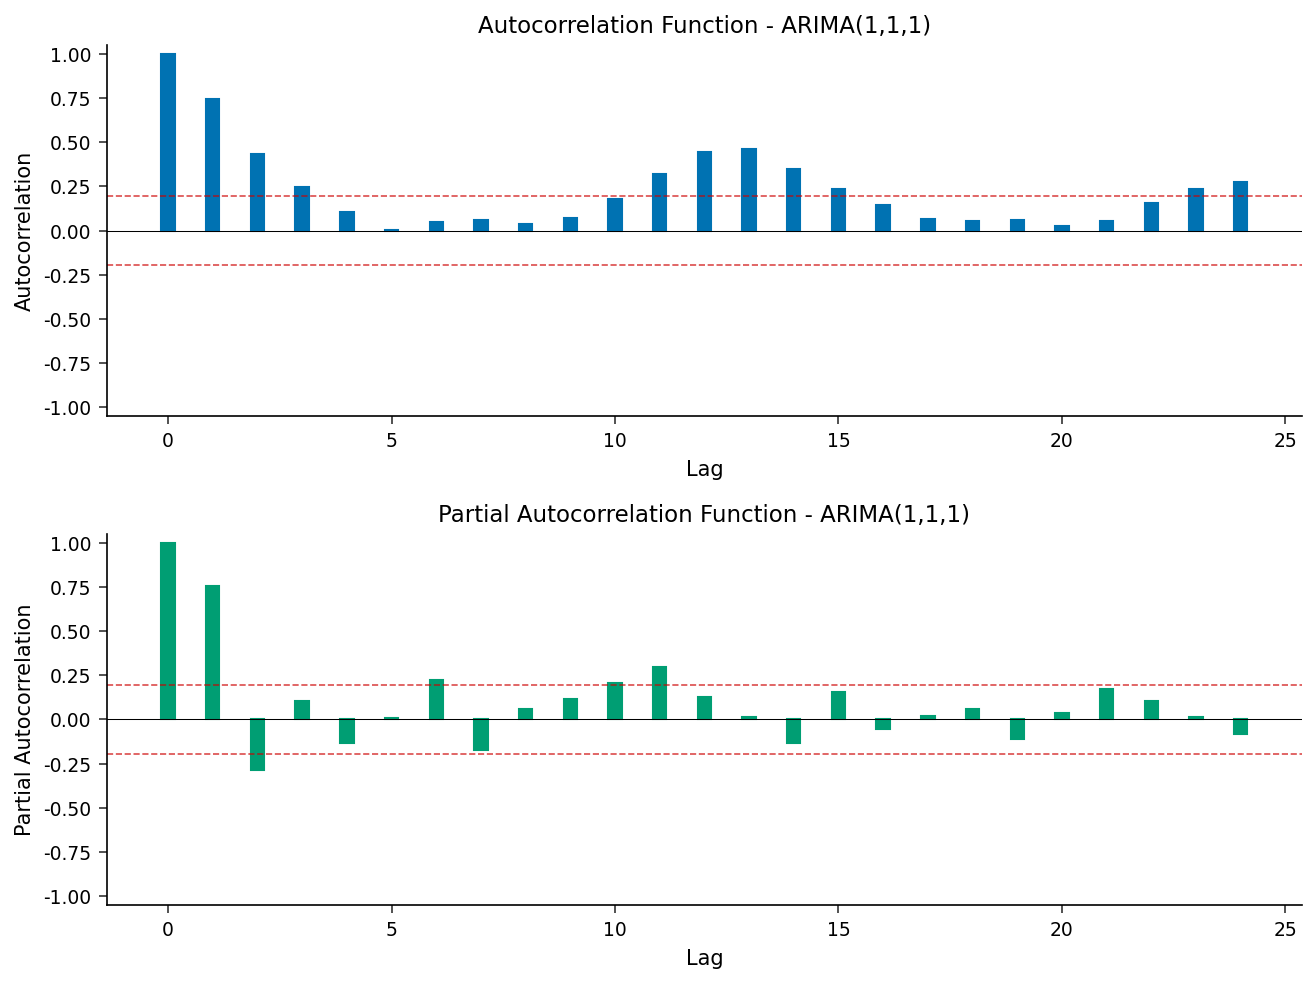

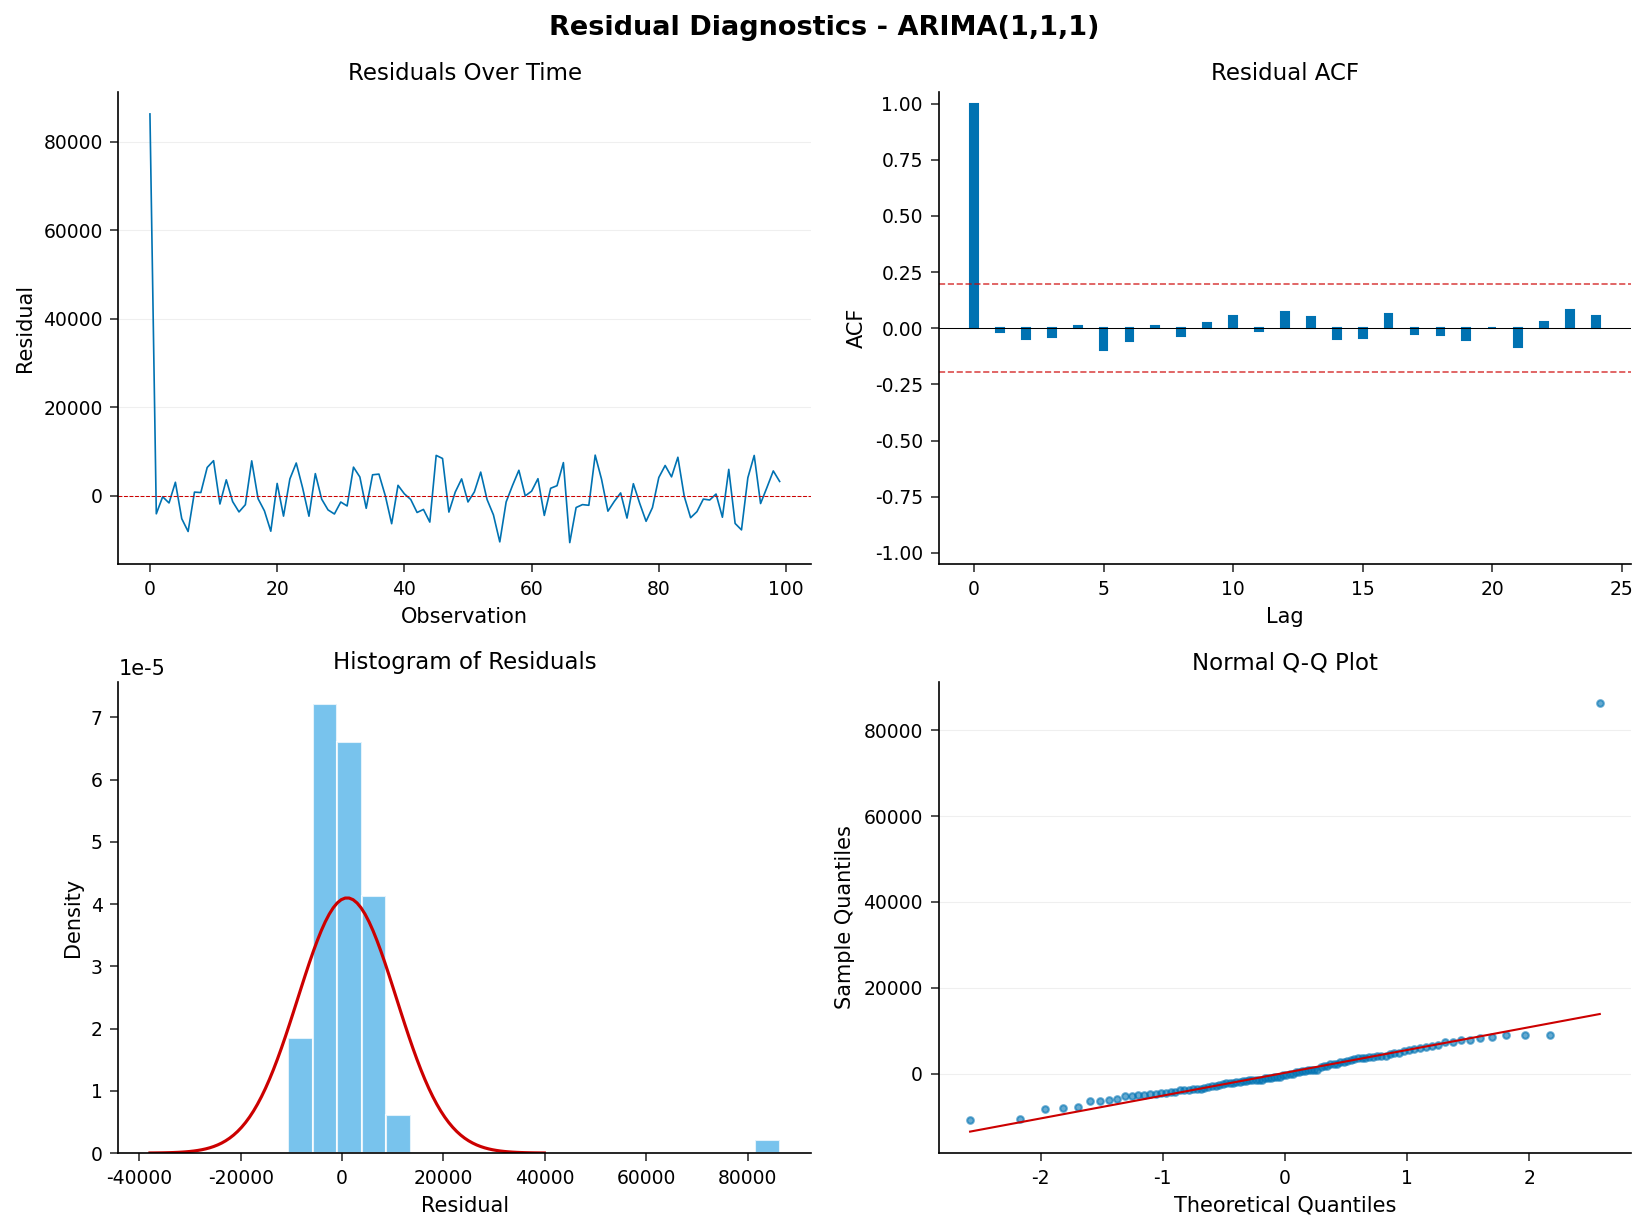

In [4]:
/* --------------------------------------------------------
   IDENTIFY + ESTIMATE i ett steg.
   IDENTIFY differentierar serien (d=1) och rapporterar ACF
   med NLAG=24; ESTIMATE anpassar ARIMA(1,1,1) med
   maximum likelihood. ODS OUTPUT fangar parameter- och
   anpassningstabellerna for dokumentation.
   -------------------------------------------------------- */
ODS UTDATA ParameterEstimates=work.arima_params
           FitStatistics=work.arima_fit;

PROCEDUR ARIMA data=work.drug_demand;
    IDENTIFY VARIABEL=fill_volume(1) NLAG=24;
    ESTIMATE p=1 q=1 METHOD=ml;
    TITEL "ARIMA(1,1,1) identifiering och skattning: läkemedelsefterfrågan";
KÖR;

ODS UTDATA CLOSE;

                             Årlig sammanfattning av läkemedelsefterfrågan: CARDIOSTAT 40MG                             

The ARIMA Procedure





NOTE: PROC ARIMA data=work.drug_demand

NOTE: Using Python statsmodels version 0.14.6
NOTE: Output dataset work.forecasts created with 112 observations.
NOTE: ODS plot written: arima_acf.spec.json
NOTE: ODS plot written: arima_forecast.spec.json
NOTE: ODS plot written: arima_diagnostics.spec.json
NOTE: PROC ARIMA completed. 1 model(s) estimated.


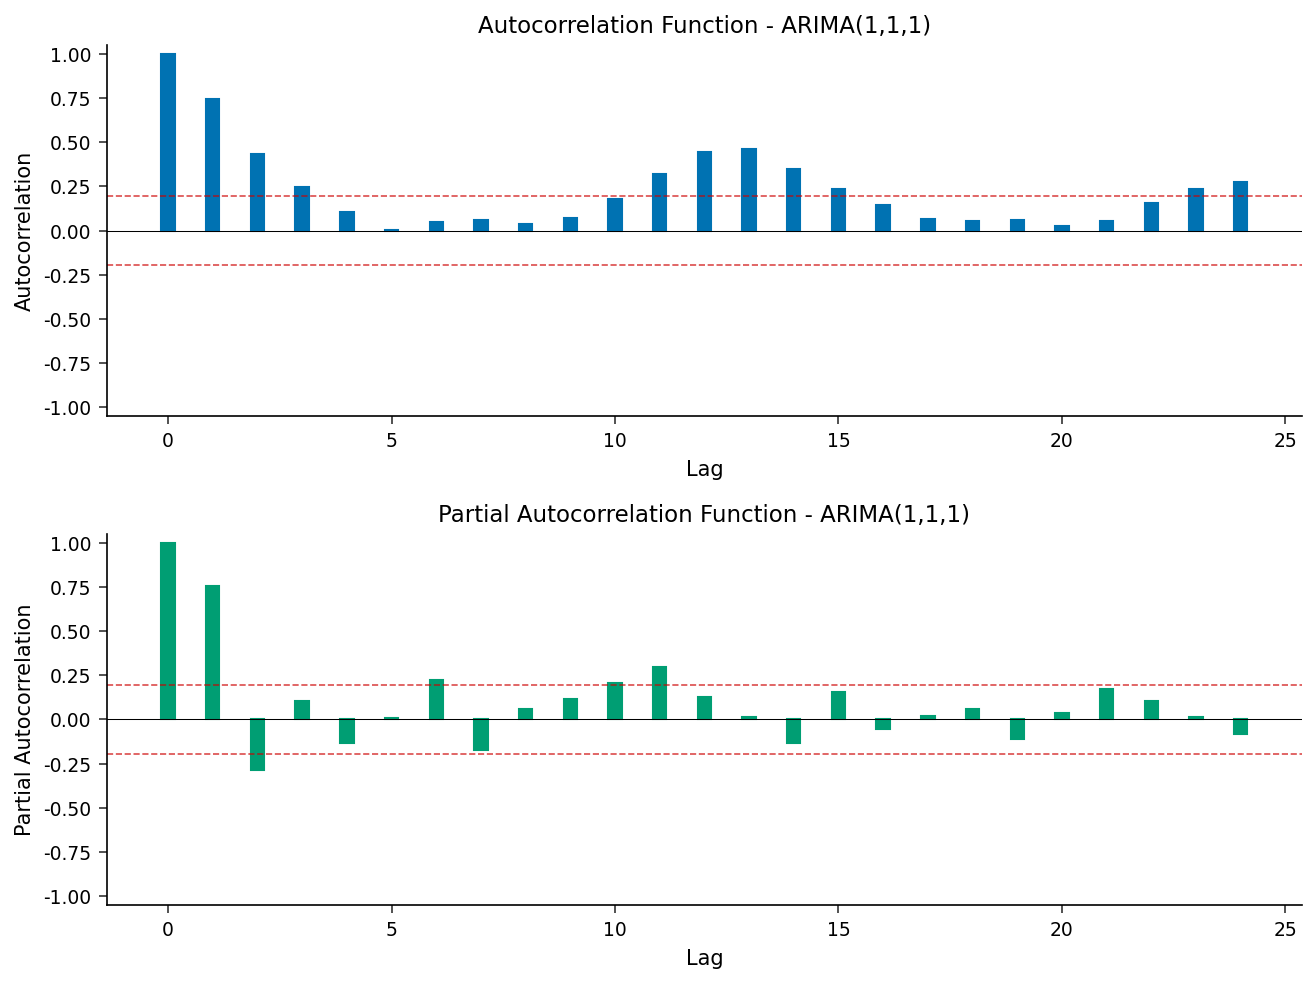

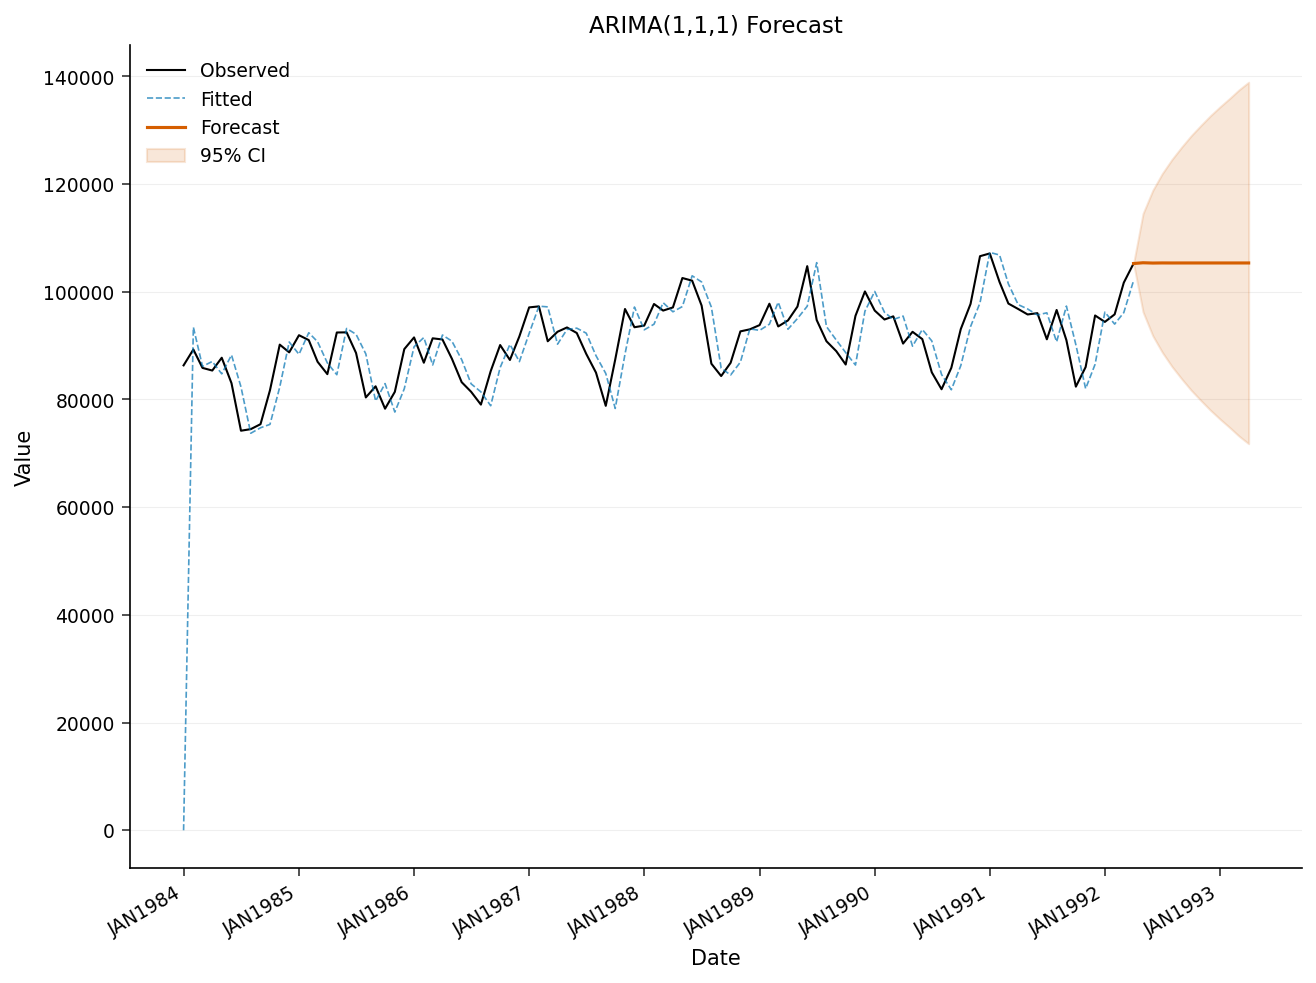

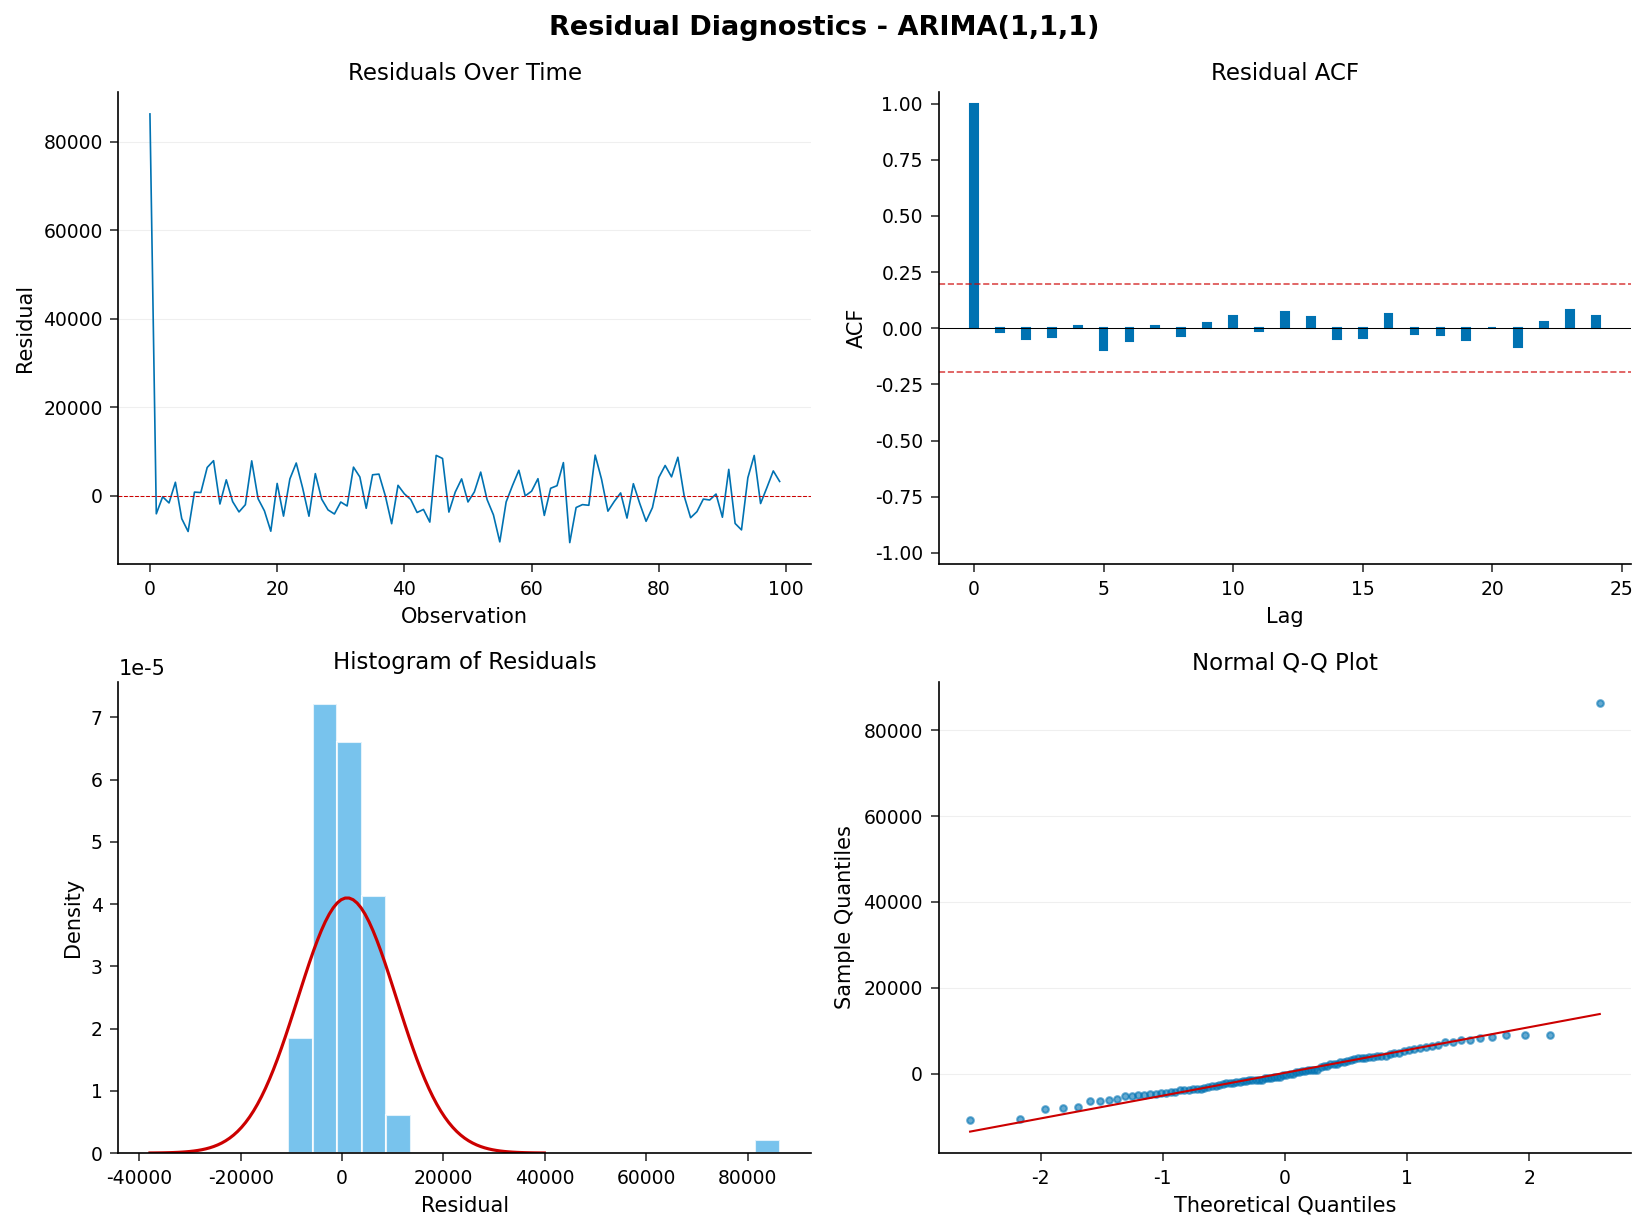

In [5]:
/* --------------------------------------------------------
   FORECAST: 12 manader framat for planering av
   forsorjningskedjan
   -------------------------------------------------------- */
PROCEDUR ARIMA data=work.drug_demand;
    IDENTIFY VARIABEL=fill_volume(1) NLAG=24 NOPRINT;
    ESTIMATE p=1 q=1 METHOD=ml NOPRINT;
    forecast LEAD=12 out=work.forecasts id=demand_date interval=month;
    TITEL "12-månaders efterfrågeprognos: CARDIOSTAT 40MG";
KÖR;

---

### Tolkning

**Identifiering.** Autokorrelationsfunktionen för den första-differentierade serien börjar på 0.74 (lagg 1) och avtar genom lagg 2-4 (0.43, 0.25, 0.11), och visar sedan en sekundär puckel runt lagg 11-14 — den kvarvarande signaturen av den årliga säsongscykeln. Detta mönster av en stark ACF av låg ordning motiverar en ARMA-modell av låg ordning på de differentierade data, och vi anpassar ARIMA(1,1,1).

**Estimering.** Maximum likelihood ger en AR(1)-koefficient på **-0.39** (standardfel 0.29, t = -1.36, p = 0.18) och en MA(1)-koefficient på **0.48** (standardfel 0.27, t = 1.75, p = 0.08). Ingen av termerna når konventionell signifikans på dessa 100 observationer, och de två nästan utsläckande termerna indikerar att den differentierade serien ligger nära vitt brus — dvs. nivåserien beter sig ungefär som en slumpvandring med drift. Modellens AIC är **1957.45** och BIC **1965.24**, med en skattad residualvarians på cirka 21.7 miljoner (residualstandardavvikelse nära 4,660 expedieringar).

**Diagnostik.** Residual-ACF:en visar inga toppar utanför banden på +/-2 standardfel bortom lagg 0, så den anpassade modellen lämnar ingen meningsfull autokorrelation kvar. Histogrammet och Q-Q-diagrammet är approximativt normala bortsett från ett enda stort värde vid den första användbara observationen, vilket är den förväntade uppstartseffekten av differentiering.

**Prognos.** Den centrala prognosen tolv månader framåt är i huvudsak platt på cirka **105,400 expedieringar per månad**, förankrad i den senast observerade nivån (105,251 expedieringar). Som en spegling av den svaga signalen vidgas det 95-procentiga prediktionsintervallet stadigt från ungefär +/-12,000 expedieringar i månad 1 till cirka **[71,800; 138,900]** vid månad 12. För planering av leveranskedjan talar detta för att dimensionera efter den centrala banan på ~105,000 expedieringar samtidigt som säkerhetslager hålls dimensionerat efter det nedre intervallet, snarare än att satsa på en kraftig säsongsuppgång som data inte stödjer.

---

In [6]:
/* --------------------------------------------------------
   Exportera ARIMA-parametertabellen for modelldokumentation
   (artefakten som refereras i den verkstallande
   sammanfattningen).
   -------------------------------------------------------- */
PROCEDUR EXPORTERA data=work.arima_params
    OUTFILE='arima_parameter_estimates.csv'
    DBMS=csv REPLACE;
KÖR;


NOTE: PROC EXPORT data=work.arima_params outfile=arima_parameter_estimates.csv

NOTE: Exported 2 rows to arima_parameter_estimates.csv.


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; Konfidentiellt
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Drivs av <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>